2 卷积和池化层

2.1 理论计算题
已知条件：
输入图像：3×32×32（通道数×高×宽）
卷积核：16个，每个大小为 3×5×5

Padding = 2，Stride = 2

1. 输出特征图尺寸计算：

输出高度/宽度公式：
H out=⌊H in+2×padding−kernel_size/stride+1⌋

H out=⌊ (32+2×2−5)/2+1⌋=⌊ (32+4−5)/2+1⌋=⌊ 31/2+1⌋=⌊15.5+1⌋=16

输出通道数 = 卷积核个数 = 16

答案： 特征图尺寸为 16×16×16

2. 单个输出通道一个像素值的乘法次数：

每个输出像素对应一个卷积核在输入上的滑动窗口。卷积核大小为 3×5×5=75 个元素。

由于输入通道数为3，每个卷积核与输入对应位置的75个元素进行点乘并求和。

答案： 需要 75 次乘法

2.2 编程题：手动实现Max Pooling

In [3]:
import numpy as np

def max_pool2d_manual(input_tensor, kernel_size, stride=None, padding=0):
    """
    手动实现二维最大池化前向传播
    
    参数:
        input_tensor: 输入张量，形状 (batch_size, channels, height, width)
        kernel_size: 池化窗口大小，可以是int或tuple (h, w)
        stride: 步幅，可以是int或tuple (h, w)，默认为kernel_size
        padding: 填充，可以是int或tuple (h, w)，默认为0
    
    返回:
        output: 池化后的输出张量
    """
    # 处理输入维度
    if len(input_tensor.shape) == 3:
        # 添加batch维度 (channels, height, width) -> (1, channels, height, width)
        input_tensor = input_tensor[np.newaxis, ...]
        added_batch = True
    else:
        added_batch = False
    
    batch_size, channels, in_h, in_w = input_tensor.shape
    
    # 参数标准化
    if isinstance(kernel_size, int):
        k_h = k_w = kernel_size
    else:
        k_h, k_w = kernel_size
    
    if stride is None:
        s_h = s_w = k_h
    elif isinstance(stride, int):
        s_h = s_w = stride
    else:
        s_h, s_w = stride
    
    if isinstance(padding, int):
        p_h = p_w = padding
    else:
        p_h, p_w = padding
    
    # 对输入进行填充
    padded_h = in_h + 2 * p_h
    padded_w = in_w + 2 * p_w
    padded_input = np.pad(input_tensor, 
                          ((0, 0), (0, 0), (p_h, p_h), (p_w, p_w)), 
                          mode='constant', constant_values=0)
    
    # 计算输出尺寸
    out_h = (padded_h - k_h) // s_h + 1
    out_w = (padded_w - k_w) // s_w + 1
    
    # 初始化输出张量
    output = np.zeros((batch_size, channels, out_h, out_w))
    
    # 执行最大池化
    for i in range(batch_size):
        for c in range(channels):
            for h in range(out_h):
                for w in range(out_w):
                    # 计算池化窗口的起始位置
                    start_h = h * s_h
                    start_w = w * s_w
                    # 提取窗口内的值
                    window = padded_input[i, c, start_h:start_h + k_h, start_w:start_w + k_w]
                    # 取最大值
                    output[i, c, h, w] = np.max(window)
    
    # 如果输入原本没有batch维度，去掉它
    if added_batch:
        output = output[0]
    
    return output


# 测试代码
if __name__ == "__main__":
    # 创建测试输入
    test_input = np.random.randn(2, 3, 32, 32)
    
    # 测试不同参数
    print("测试1: kernel_size=2, stride=2, padding=0")
    output1 = max_pool2d_manual(test_input, kernel_size=2, stride=2, padding=0)
    print(f"输入形状: {test_input.shape}")
    print(f"输出形状: {output1.shape}")
    
    print("\n测试2: kernel_size=3, stride=2, padding=1")
    output2 = max_pool2d_manual(test_input, kernel_size=3, stride=2, padding=1)
    print(f"输入形状: {test_input.shape}")
    print(f"输出形状: {output2.shape}")
    
    print("\n测试3: 三维输入 (channels, height, width)")
    test_input_3d = np.random.randn(3, 32, 32)
    output3 = max_pool2d_manual(test_input_3d, kernel_size=2, stride=2)
    print(f"输入形状: {test_input_3d.shape}")
    print(f"输出形状: {output3.shape}")

测试1: kernel_size=2, stride=2, padding=0
输入形状: (2, 3, 32, 32)
输出形状: (2, 3, 16, 16)

测试2: kernel_size=3, stride=2, padding=1
输入形状: (2, 3, 32, 32)
输出形状: (2, 3, 16, 16)

测试3: 三维输入 (channels, height, width)
输入形状: (3, 32, 32)
输出形状: (3, 16, 16)


3 LeNet, AlexNet, VGG 和 NiN

3.1 理论计算题
已知条件： 输入和输出特征图通道数均为 C
1. 单个 5×5 卷积层（不带偏置）的参数量：

参数量 = 输入通道数 × 卷积核高 × 卷积核宽 × 输出通道数
Params 5×5=C×5×5×C=25C^2
 
2. 两个串联的 3×3 卷积层（不带偏置）的总参数量：

第一层：C×3×3×C=9C^2
第二层：C×3×3×C=9C^2
总参数量 = 9C^2+9C^2=18C^2

结论： 两个 3×3 卷积层比一个 5×5 卷积层少 7C^2个参数，同时具有更大的感受野（两个 
3×3 有效感受野为 5×5）

3.2 编程题：NiN Block

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    """
    NiN块 (Network in Network Block)
    
    结构：
        1. 普通卷积层 (kernel_size, stride, padding)
        2. ReLU激活
        3. 1x1卷积层
        4. ReLU激活
        5. 1x1卷积层
        6. ReLU激活
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(NiNBlock, self).__init__()
        
        self.block = nn.Sequential(
            # 普通卷积层
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(inplace=True),
            # 第一个1x1卷积层 (相当于全连接层)
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            # 第二个1x1卷积层
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.block(x)


# 测试代码
if __name__ == "__main__":
    # 创建NiN块实例
    nin_block = NiNBlock(in_channels=3, out_channels=96, kernel_size=3, stride=1, padding=1)
    
    # 创建测试输入
    test_input = torch.randn(4, 3, 32, 32)  # batch=4, channels=3, height=32, width=32
    
    # 前向传播
    output = nin_block(test_input)
    
    print("NiN Block测试:")
    print(f"输入形状: {test_input.shape}")
    print(f"输出形状: {output.shape}")
    print(f"\nNiN Block结构:")
    print(nin_block)

NiN Block测试:
输入形状: torch.Size([4, 3, 32, 32])
输出形状: torch.Size([4, 96, 32, 32])

NiN Block结构:
NiNBlock(
  (block): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU(inplace=True)
  )
)


4 Inception，批量归一化和残差网络

4.1 理论计算题
已知条件：

样本值：x1=2,x2=4,x3=6,x4=8
γ=2,β=1,ϵ=0

计算步骤：

1.计算均值 μB：
μB= （2+4+6+8）/4= 20/4=5

2.计算方差 σB^2：
σB^2=((2−5)^2 +(4−5)^2 +(6−5)^2 +(8−5)^2)/4 = (9+1+1+9)/4= 20/4=5

3.归一化：x^i= (xi​−μB)/√(σB^2+ϵ)
x^1= (2−5)/√5= -3/√5
​x^2= (4−5)/√5= -1/√5
x^3= (6−5)/√5= 1/√5
x^4= (8−5)/√5= 3/√5

缩放和平移：yi=γx^i+β
y1=2× (-3/√5)+1=(-6/√5)+1
y2=2× (-1/√5)+1=(-2/√5)+1
y3=2× (1/√5)+1=(2/√5)+1
y4=2× (3/√5)+1=(6/√5)+1


​
 




4.2 编程题：残差块 (Residual Block)

In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn

class Residual(nn.Module):
    """
    残差块 (Residual Block)
    
    结构：
        f(x) = Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN
        输出 = f(x) + x (如果use_1x1conv=True，则先对x进行1x1卷积调整)
    """
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super(Residual, self).__init__()
        
        # 第一个卷积层
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        # 第二个卷积层
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 1x1卷积层（用于调整输入的形状和通道数）
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels, out_channels, kernel_size=1, 
                                   stride=stride)
        else:
            self.conv3 = None
    
    def forward(self, x):
        # 保存输入用于残差连接
        identity = x
        
        # 第一个卷积块
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # 第二个卷积块
        out = self.conv2(out)
        out = self.bn2(out)
        
        # 调整输入的形状（如果需要）
        if self.conv3 is not None:
            identity = self.conv3(identity)
        
        # 残差连接
        out += identity
        out = self.relu(out)
        
        return out


# 测试代码
if __name__ == "__main__":
    print("残差块测试:")
    
    # 测试1: 输入输出通道相同，不需要1x1卷积
    block1 = Residual(in_channels=64, out_channels=64, use_1x1conv=False)
    test_input1 = torch.randn(4, 64, 32, 32)
    output1 = block1(test_input1)
    print(f"测试1 - 输入: {test_input1.shape} -> 输出: {output1.shape}")
    
    # 测试2: 输入输出通道不同，需要1x1卷积
    block2 = Residual(in_channels=32, out_channels=64, use_1x1conv=True, stride=2)
    test_input2 = torch.randn(4, 32, 32, 32)
    output2 = block2(test_input2)
    print(f"测试2 - 输入: {test_input2.shape} -> 输出: {output2.shape}")
    
    print(f"\n残差块结构:")
    print(block2)

残差块测试:
测试1 - 输入: torch.Size([4, 64, 32, 32]) -> 输出: torch.Size([4, 64, 32, 32])
测试2 - 输入: torch.Size([4, 32, 32, 32]) -> 输出: torch.Size([4, 64, 16, 16])

残差块结构:
Residual(
  (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2))
)


5 图像增广，微调和样式迁移

5.1 理论计算题
1. 为什么底层特征提取层使用小学习率，顶层输出层使用大学习率？

底层特征提取层：这些层学习的是通用特征（如边缘、纹理、颜色等），在源数据集（如ImageNet）上已经训练得很好，这些特征具有很好的迁移性。使用小学习率可以：

保留预训练学到的通用特征

防止破坏已有知识

避免过拟合小规模目标数据集

冻结这些层可以大大减少训练参数，加速训练

顶层输出层：这些层学习的是任务相关的特征，在新数据集上需要重新学习。使用大学习率可以：

快速适应新数据集的类别分布

帮助模型学习新的任务特定特征

2. 目标数据集很小且与源数据集非常相似时的微调策略：

冻结大部分底层特征提取层，只微调最后几层

使用较小的学习率进行微调

使用更强的正则化：

Dropout

权重衰减（L2正则化）

早停法

使用数据增广（如翻转、裁剪、颜色变换等）来扩充小数据集

减少模型复杂度或使用更简单的分类器

5.2 编程题：图像增广Pipeline

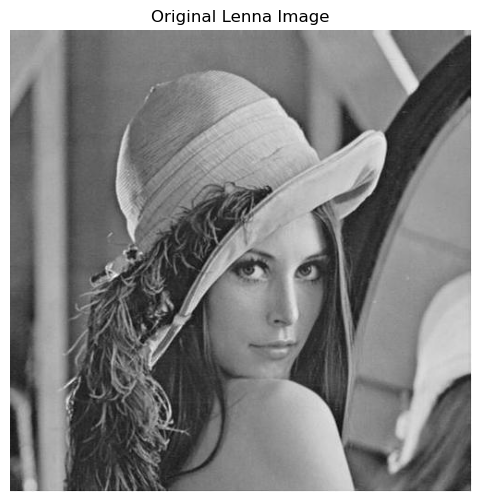

原始图像尺寸: (500, 501)
原始图像模式: RGB
原始图像 numpy 形状: (501, 500, 3)


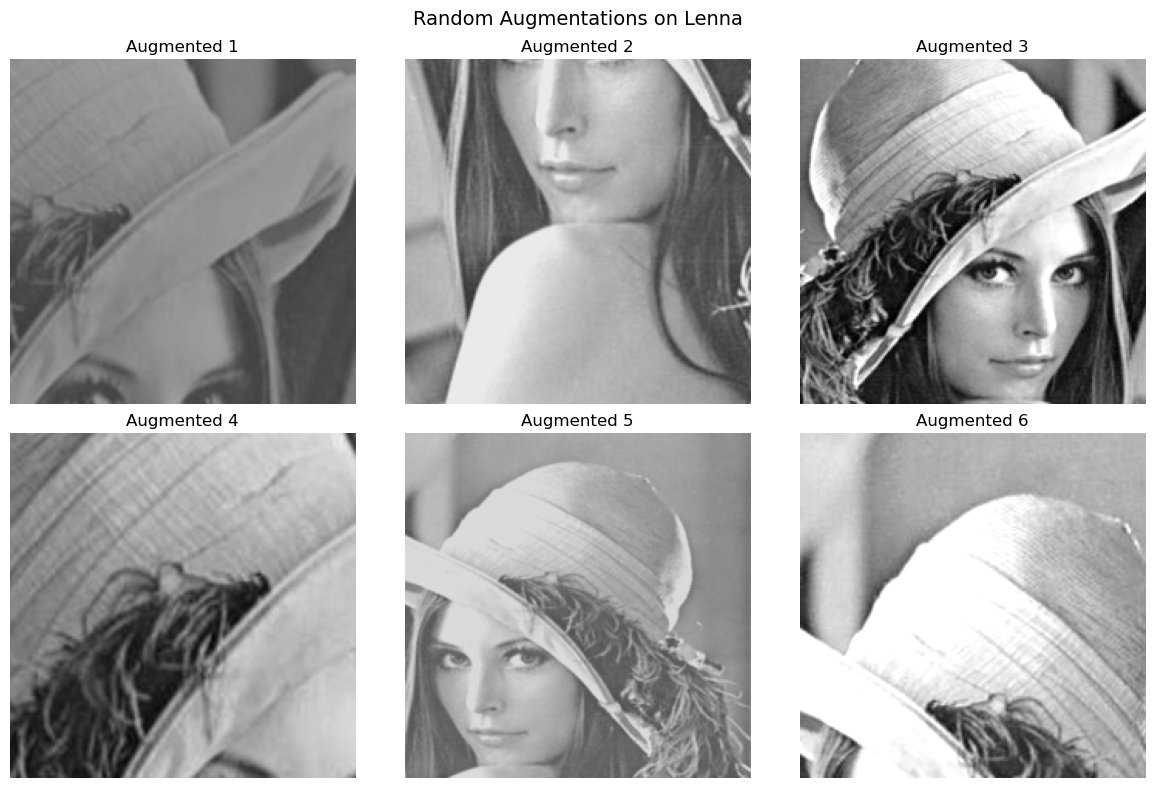


【验证任务要求】
输出类型: <class 'torch.Tensor'>
输出形状: torch.Size([3, 224, 224])  # 应为 (3, 224, 224)
✅ 已完成所有任务点:
1. 随机裁剪+缩放 224x224
2. 50% 概率水平翻转
3. 亮度/对比度/饱和度变化范围 = 0.5
4. 最终转换为 PyTorch Tensor


In [8]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# ============================================================
# 1. 导入测试图像（lenna图）
# ============================================================
image_path = "D:/深度学习课程/lenna.jpeg"  # 请根据实际路径调整

# 使用 PIL 打开图像（支持中文路径）
image = Image.open(image_path).convert('RGB')

# 转为 numpy 用于展示（可选）
image_np = np.array(image)

# 展示原始图像
plt.figure(figsize=(6, 6))
plt.imshow(image_np)
plt.title("Original Lenna Image")
plt.axis("off")
plt.show()

print(f"原始图像尺寸: {image.size}")
print(f"原始图像模式: {image.mode}")
print(f"原始图像 numpy 形状: {image_np.shape}")

# ============================================================
# 2. 构建图像增广 Pipeline
# ============================================================
augmentation_pipeline = transforms.Compose([
    # 任务点1：随机裁剪（面积比例 0.08~1.0）并缩放到 224x224
    transforms.RandomResizedCrop(
        size=224,          # 输出尺寸
        scale=(0.08, 1.0), # 裁剪区域占原图面积的比例范围
        ratio=(3.0/4.0, 4.0/3.0)  # 宽高比范围（保持合理形状，非强制要求但推荐）
    ),
    
    # 任务点2：50% 概率水平翻转
    transforms.RandomHorizontalFlip(p=0.5),
    
    # 任务点3：随机改变亮度、对比度、饱和度，变化范围 = 0.5
    # 注意：这里是三个独立范围，每个都是 0.5，不是总和或乘积
    transforms.ColorJitter(
        brightness=0.5,   # 亮度变化范围 [1-0.5, 1+0.5]
        contrast=0.5,     # 对比度变化范围 [1-0.5, 1+0.5]
        saturation=0.5    # 饱和度变化范围 [1-0.5, 1+0.5]
    ),
    
    # 任务点4：转换为 PyTorch Tensor (C, H, W)，值域 [0, 1]
    transforms.ToTensor()
])

# ============================================================
# 3. 对同一张图像多次应用增广，展示效果
# ============================================================
num_samples = 6  # 展示 6 个不同的增广版本

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(num_samples):
    # 每次应用完整的增广 pipeline
    augmented_tensor = augmentation_pipeline(image)
    
    # 转为 numpy 用于显示 (C, H, W) -> (H, W, C)
    augmented_np = augmented_tensor.permute(1, 2, 0).numpy()
    
    # 显示
    axes[i].imshow(augmented_np)
    axes[i].set_title(f"Augmented {i+1}")
    axes[i].axis("off")

plt.suptitle("Random Augmentations on Lenna", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 4. 验证输出是否为 Tensor 以及形状
# ============================================================
print("\n【验证任务要求】")
print(f"输出类型: {type(augmented_tensor)}")
print(f"输出形状: {augmented_tensor.shape}  # 应为 (3, 224, 224)")
print("✅ 已完成所有任务点:")
print("1. 随机裁剪+缩放 224x224")
print("2. 50% 概率水平翻转")
print("3. 亮度/对比度/饱和度变化范围 = 0.5")
print("4. 最终转换为 PyTorch Tensor")



6 目标检测，计算机视觉训练技巧

6.1 理论计算题
已知条件：

真实框 A=[10,10,50,50]

预测框 B=[30,30,70,70]

计算IoU：

1.计算交集矩形：

x1 inter=max(10,30)=30

y1 inter=max(10,30)=30

x2 inter=min(50,70)=50

y2 inter=min(50,70)=50

交集宽度 =50−30=20

交集高度 =50−30=20

交集面积 =20×20=400

2.计算各自面积：

Area A=(50−10)×(50−10)=40×40=1600

Area B=(70−30)×(70−30)=40×40=1600

3.计算并集面积：

Union=Area A+Area B−Intersection=1600+1600−400=2800

4.计算IoU：

IoU= Intersection/Union=400/2800 = 1/7≈0.1429

答案： IoU= 1/7≈0.1429

6.2 编程题：标签平滑交叉熵损失

In [10]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.nn.functional as F

class LabelSmoothingCrossEntropy(nn.Module):
    """
    标签平滑交叉熵损失函数
    
    参数:
        epsilon: 平滑因子，默认为0.1
        reduction: 损失缩减方式 ('none', 'mean', 'sum')
    """
    def __init__(self, epsilon=0.1, reduction='mean'):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.epsilon = epsilon
        self.reduction = reduction
    
    def forward(self, predictions, targets):
        """
        计算标签平滑后的交叉熵损失
        
        参数:
            predictions: 模型预测值，形状 (batch_size, num_classes)
            targets: 真实标签，形状 (batch_size,)
        
        返回:
            loss: 计算得到的损失值
        """
        num_classes = predictions.size(-1)
        batch_size = predictions.size(0)
        
        # 将预测值转换为log_softmax形式（数值稳定）
        log_probs = F.log_softmax(predictions, dim=-1)
        
        # 创建平滑后的目标分布
        # 真实类别概率: 1 - epsilon
        # 其他类别概率: epsilon / (num_classes - 1)
        smooth_targets = torch.zeros_like(log_probs)
        smooth_targets.fill_(self.epsilon / (num_classes - 1))
        
        # 设置真实类别的概率
        smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.epsilon)
        
        # 计算损失: -sum(y_smooth * log(p))
        loss = -torch.sum(smooth_targets * log_probs, dim=-1)
        
        # 根据reduction参数缩减损失
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:  # 'none'
            return loss


# 简化版本（使用F.cross_entropy的label_smoothing参数，PyTorch 1.10+）
class LabelSmoothingCrossEntropySimple(nn.Module):
    """
    使用PyTorch内置label_smoothing参数的简化版本
    需要PyTorch 1.10及以上版本
    """
    def __init__(self, epsilon=0.1, reduction='mean'):
        super(LabelSmoothingCrossEntropySimple, self).__init__()
        self.epsilon = epsilon
        self.reduction = reduction
    
    def forward(self, predictions, targets):
        return F.cross_entropy(
            predictions, 
            targets, 
            label_smoothing=self.epsilon,
            reduction=self.reduction
        )


# 测试代码
if __name__ == "__main__":
    print("=" * 50)
    print("标签平滑交叉熵损失测试")
    print("=" * 50)
    
    # 设置随机种子
    torch.manual_seed(42)
    
    # 测试参数
    batch_size = 4
    num_classes = 10
    epsilon = 0.1
    
    # 创建随机预测和真实标签
    predictions = torch.randn(batch_size, num_classes)
    targets = torch.tensor([0, 2, 3, 5])  # 真实类别
    
    print(f"预测值形状: {predictions.shape}")
    print(f"真实标签: {targets}")
    print(f"类别数: {num_classes}")
    print(f"平滑因子 epsilon: {epsilon}")
    
    # 测试自定义实现
    print("\n" + "=" * 30)
    print("自定义实现")
    print("=" * 30)
    
    criterion_custom = LabelSmoothingCrossEntropy(epsilon=epsilon, reduction='none')
    losses_custom = criterion_custom(predictions, targets)
    loss_mean_custom = losses_custom.mean()
    
    print(f"每个样本的损失: {losses_custom}")
    print(f"平均损失: {loss_mean_custom.item():.4f}")
    
    # 测试简化版本（如果PyTorch版本支持）
    print("\n" + "=" * 30)
    print("简化版本 (PyTorch内置)")
    print("=" * 30)
    
    try:
        criterion_simple = LabelSmoothingCrossEntropySimple(epsilon=epsilon)
        loss_simple = criterion_simple(predictions, targets)
        print(f"平均损失: {loss_simple.item():.4f}")
        
        # 验证一致性
        print(f"\n两种方法差异: {abs(loss_mean_custom.item() - loss_simple.item()):.6f}")
    except Exception as e:
        print(f"简化版本可能不兼容当前PyTorch版本: {e}")
    
    # 演示标签平滑的效果
    print("\n" + "=" * 30)
    print("标签平滑效果演示")
    print("=" * 30)
    
    # 对比标准交叉熵和标签平滑交叉熵
    criterion_ce = nn.CrossEntropyLoss(reduction='mean')
    loss_ce = criterion_ce(predictions, targets)
    
    print(f"标准交叉熵损失: {loss_ce.item():.4f}")
    print(f"标签平滑交叉熵损失: {loss_mean_custom.item():.4f}")
    print(f"损失差异: {abs(loss_ce.item() - loss_mean_custom.item()):.4f}")
    
    # 演示当模型非常自信时标签平滑的效果
    print("\n" + "=" * 30)
    print("模型非常自信的情况")
    print("=" * 30)
    
    # 创建非常自信的预测（一个类别概率接近1）
    confident_predictions = torch.zeros(batch_size, num_classes)
    for i, target in enumerate(targets):
        confident_predictions[i, target] = 10.0  # logit值很大
    
    loss_ce_confident = criterion_ce(confident_predictions, targets)
    loss_smooth_confident = criterion_custom(confident_predictions, targets).mean()
    
    print(f"标准交叉熵损失 (自信预测): {loss_ce_confident.item():.4f}")
    print(f"标签平滑损失 (自信预测): {loss_smooth_confident.item():.4f}")
    print("注: 标签平滑防止模型过于自信，即使预测正确也会保留一定的损失")

标签平滑交叉熵损失测试
预测值形状: torch.Size([4, 10])
真实标签: tensor([0, 2, 3, 5])
类别数: 10
平滑因子 epsilon: 0.1

自定义实现
每个样本的损失: tensor([1.4113, 3.2120, 1.6343, 0.9394])
平均损失: 1.7992

简化版本 (PyTorch内置)
平均损失: 1.7859

两种方法差异: 0.013311

标签平滑效果演示
标准交叉熵损失: 1.6661
标签平滑交叉熵损失: 1.7992
损失差异: 0.1331

模型非常自信的情况
标准交叉熵损失 (自信预测): 0.0004
标签平滑损失 (自信预测): 1.0004
注: 标签平滑防止模型过于自信，即使预测正确也会保留一定的损失
